In [29]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing(as_frame=True)
features = housing.data
target = housing.target.to_frame(name="MedHouseValue")
df = pd.concat([features, target], axis=1)

csv_path = Path("dataset/california_housing.csv")
csv_path.parent.mkdir(parents=True, exist_ok=True)
if not csv_path.exists():
    df.to_csv(csv_path, index=False)

# 1. Data Inspection
### This section performs initial exploratory data analysis (EDA) on the dataset to understand its structure and characteristics.

**Operations:**

- **df.head()**: Displays the first few rows of the dataset
    - *Importance*: Provides a quick visual overview of the data format and sample values
    - *When to use*: At the start of analysis to verify data loaded correctly and understand column names/types

- **df.info()**: Shows data types and non-null value counts for each column
    - *Importance*: Identifies missing values and data type inconsistencies that may require preprocessing
    - *When to use*: When checking for data quality issues and memory usage before modeling

- **df.shape**: Returns the number of rows and columns in the dataset
    - *Importance*: Essential for understanding dataset size and planning train/validation/test splits
    - *When to use*: When determining computational feasibility and designing data partitioning strategy

- **df.nunique()**: Counts distinct values in each column
    - *Importance*: Helps identify categorical vs continuous features and detects potential outliers/errors
    - *When to use*: When determining which features need encoding and which are already numeric

- **df.describe()**: Generates descriptive statistics (mean, std, min, max, quartiles)
    - *Importance*: Reveals data distribution, range, and potential outliers/anomalies
    - *When to use*: When understanding feature scales, distributions, and whether normalization/scaling is needed

In [ ]:
# View data to see the first 5 rows
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseValue
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [9]:
# To check the datatype and the no. of filled values in each feature
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
dtypes: float64(8)
memory usage: 1.3 MB


In [ ]:
# To check the no. of row and columns. Useful for train/val/test split of data
df.shape()

(20640, 8)

In [12]:
# To see all the distinct no. of values in each feature. Useful to identify categorical features
df.nunique()

MedInc        12928
HouseAge         52
AveRooms      19392
AveBedrms     14233
Population     3888
AveOccup      18841
Latitude        862
Longitude       844
dtype: int64

In [13]:
# Gives basic statistics of each feature.
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000


In [6]:
df.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64

# 2. Column-wise Analysis

This section looks at each column one by one to understand the data better.

### Goals
- Check basic statistics for each column.
- Find the center, spread, and shape of the data.
- Detect outliers.
- Plot distributions to see how the values are spread.

### What each check tells us
- **`df.head()`**: Shows a few rows so we can quickly inspect the data.
- **`df.info()`**: Shows data types and missing values.
- **`df.shape`**: Shows how many rows and columns the dataset has.
- **`df.nunique()`**: Shows how many unique values each column has.
- **`df.describe()`**: Gives summary statistics such as:
    - **mean** and **median** for center;
    - **std** for spread;
    - **min** and **max** for range;
    - **Q1** and **Q3** for quartiles.
- **Typical range (`mean ± std`)**: Gives a quick idea of where most values are.
- **IQR and outlier limits**:
    - `IQR = Q3 - Q1`
    - `lower_limit = Q1 - 1.5 × IQR`
    - `upper_limit = Q3 + 1.5 × IQR`
    - Count values outside these limits to find outliers.
- **Missing values**: Use `df.isnull().sum()` to see if any column has missing data.
- **Distribution shape**:
    - If mean and median are close, the data is roughly symmetric.
    - If mean is larger than median, the data is likely right-skewed.
    - If mean is smaller than median, the data is likely left-skewed.
- **KDE plots**: Help visualize the shape of each column’s distribution.

### Why this matters
- Many outliers or strong skew may need transformation or robust methods.
- Missing values may need imputation or removal.
- Very few unique values may mean a feature is categorical or not very useful.

In [22]:
medinc = df['MedInc']
print(medinc.describe())
print()
print(f"Majority values range: {medinc.mean() - medinc.std()} to {medinc.mean() + medinc.std()}")
print(f"Mean: {medinc.mean()}")
print(f"Median: {medinc.median()}")

q1 = medinc.quantile(0.25)
q3 = medinc.quantile(0.75)
iqr = q3 - q1
print(f"First quartile (Q1): {q1}")
print(f"Third quartile (Q3): {q3}")
print(f"Interquartile Range: {iqr}")
lower_limit = q1 - 1.5 * iqr
upper_limit = q3 + 1.5 * iqr
print(f"Lower limit: {lower_limit}")
print(f"Upper limit: {upper_limit}")

below_lower = (medinc < lower_limit).sum()
above_upper = (medinc > upper_limit).sum()
print(f"Outliers below lower limit: {below_lower}")
print(f"Outliers above upper limit: {above_upper}")

mean = medinc.mean()
median = medinc.median()

if np.isclose(mean, median, rtol=0.05, atol=0.05):
    print("Distribution shape: symmetric distribution")
elif mean > median:
    print("Distribution shape: Possible right skewed")
else:
    print("Distribution shape: Possible left skewed")

count    20640.000000
mean         3.870671
std          1.899822
min          0.499900
25%          2.563400
50%          3.534800
75%          4.743250
max         15.000100
Name: MedInc, dtype: float64

Majority values range: 1.9708492849617079 to 5.770492720852245
Mean: 3.8706710029069766
Median: 3.5347999999999997
First quartile (Q1): 2.5633999999999997
Third quartile (Q3): 4.74325
Interquartile Range: 2.17985
Lower limit: -0.7063750000000004
Upper limit: 8.013024999999999
Outliers below lower limit: 0
Outliers above upper limit: 681
Distribution shape: Possible right skewed


In [23]:
house_age = df['HouseAge']
print(house_age.describe())
print()
print("Column Name: HouseAge")
print(f"Column type: {type(house_age)}")
print(f"Typical range: {house_age.mean() - house_age.std()} to {house_age.mean() + house_age.std()}")
print(f"Mean: {house_age.mean()}")
print(f"Median: {house_age.median()}")

q1 = house_age.quantile(0.25)
q3 = house_age.quantile(0.75)
iqr = q3 - q1
print(f"First quartile (Q1): {q1}")
print(f"Third quartile (Q3): {q3}")
print(f"Interquartile Range: {iqr}")
lower_limit = q1 - 1.5 * iqr
upper_limit = q3 + 1.5 * iqr
print(f"Lower limit: {lower_limit}")
print(f"Upper limit: {upper_limit}")

below_lower = (house_age < lower_limit).sum()
above_upper = (house_age > upper_limit).sum()
print(f"Outliers below lower limit: {below_lower}")
print(f"Outliers above upper limit: {above_upper}")

mean = house_age.mean()
median = house_age.median()

if np.isclose(mean, median, rtol=0.05, atol=0.05):
    print("Distribution shape: symmetric distribution")
elif mean > median:
    print("Distribution shape: right skewed")
else:
    print("Distribution shape: left skewed")

count    20640.000000
mean        28.639486
std         12.585558
min          1.000000
25%         18.000000
50%         29.000000
75%         37.000000
max         52.000000
Name: HouseAge, dtype: float64

Column Name: HouseAge
Column type: <class 'pandas.Series'>
Typical range: 16.053928821996877 to 41.22504404622018
Mean: 28.639486434108527
Median: 29.0
First quartile (Q1): 18.0
Third quartile (Q3): 37.0
Interquartile Range: 19.0
Lower limit: -10.5
Upper limit: 65.5
Outliers below lower limit: 0
Outliers above upper limit: 0
Distribution shape: symmetric distribution


In [24]:
ave_rooms = df['AveRooms']
print(ave_rooms.describe())
print()
print("Column Name: AveRooms")
print(f"Column type: {type(ave_rooms)}")
print(f"Typical range: {ave_rooms.mean() - ave_rooms.std()} to {ave_rooms.mean() + ave_rooms.std()}")
print(f"Mean: {ave_rooms.mean()}")
print(f"Median: {ave_rooms.median()}")

q1 = ave_rooms.quantile(0.25)
q3 = ave_rooms.quantile(0.75)
iqr = q3 - q1
print(f"First quartile (Q1): {q1}")
print(f"Third quartile (Q3): {q3}")
print(f"Interquartile Range: {iqr}")
lower_limit = q1 - 1.5 * iqr
upper_limit = q3 + 1.5 * iqr
print(f"Lower limit: {lower_limit}")
print(f"Upper limit: {upper_limit}")

below_lower = (ave_rooms < lower_limit).sum()
above_upper = (ave_rooms > upper_limit).sum()
print(f"Outliers below lower limit: {below_lower}")
print(f"Outliers above upper limit: {above_upper}")

mean = ave_rooms.mean()
median = ave_rooms.median()

if np.isclose(mean, median, rtol=0.05, atol=0.05):
    print("Distribution shape: symmetric distribution")
elif mean > median:
    print("Distribution shape: right skewed")
else:
    print("Distribution shape: left skewed")

count    20640.000000
mean         5.429000
std          2.474173
min          0.846154
25%          4.440716
50%          5.229129
75%          6.052381
max        141.909091
Name: AveRooms, dtype: float64

Column Name: AveRooms
Column type: <class 'pandas.Series'>
Typical range: 2.9548266027660572 to 7.903172881614695
Mean: 5.428999742190376
Median: 5.229128787878788
First quartile (Q1): 4.440716235896959
Third quartile (Q3): 6.052380952380952
Interquartile Range: 1.6116647164839932
Lower limit: 2.023219161170969
Upper limit: 8.469878027106942
Outliers below lower limit: 45
Outliers above upper limit: 466
Distribution shape: symmetric distribution


In [25]:
ave_bedrms = df['AveBedrms']
print(ave_bedrms.describe())
print()
print("Column Name: AveBedrms")
print(f"Column type: {type(ave_bedrms)}")
print(f"Typical range: {ave_bedrms.mean() - ave_bedrms.std()} to {ave_bedrms.mean() + ave_bedrms.std()}")
print(f"Mean: {ave_bedrms.mean()}")
print(f"Median: {ave_bedrms.median()}")

q1 = ave_bedrms.quantile(0.25)
q3 = ave_bedrms.quantile(0.75)
iqr = q3 - q1
print(f"First quartile (Q1): {q1}")
print(f"Third quartile (Q3): {q3}")
print(f"Interquartile Range: {iqr}")
lower_limit = q1 - 1.5 * iqr
upper_limit = q3 + 1.5 * iqr
print(f"Lower limit: {lower_limit}")
print(f"Upper limit: {upper_limit}")

below_lower = (ave_bedrms < lower_limit).sum()
above_upper = (ave_bedrms > upper_limit).sum()
print(f"Outliers below lower limit: {below_lower}")
print(f"Outliers above upper limit: {above_upper}")

mean = ave_bedrms.mean()
median = ave_bedrms.median()

if np.isclose(mean, median, rtol=0.05, atol=0.05):
    print("Distribution shape: symmetric distribution")
elif mean > median:
    print("Distribution shape: right skewed")
else:
    print("Distribution shape: left skewed")

count    20640.000000
mean         1.096675
std          0.473911
min          0.333333
25%          1.006079
50%          1.048780
75%          1.099526
max         34.066667
Name: AveBedrms, dtype: float64

Column Name: AveBedrms
Column type: <class 'pandas.Series'>
Typical range: 0.622764292810742 to 1.570586006401674
Mean: 1.096675149606208
Median: 1.048780487804878
First quartile (Q1): 1.006079046038478
Third quartile (Q3): 1.099526066350711
Interquartile Range: 0.09344702031223284
Lower limit: 0.8659085155701288
Upper limit: 1.2396965968190603
Outliers below lower limit: 188
Outliers above upper limit: 1236
Distribution shape: symmetric distribution


In [26]:
population = df['Population']
print(population.describe())
print()
print("Column Name: Population")
print(f"Column type: {type(population)}")
print(f"Typical range: {population.mean() - population.std()} to {population.mean() + population.std()}")
print(f"Mean: {population.mean()}")
print(f"Median: {population.median()}")

q1 = population.quantile(0.25)
q3 = population.quantile(0.75)
iqr = q3 - q1
print(f"First quartile (Q1): {q1}")
print(f"Third quartile (Q3): {q3}")
print(f"Interquartile Range: {iqr}")
lower_limit = q1 - 1.5 * iqr
upper_limit = q3 + 1.5 * iqr
print(f"Lower limit: {lower_limit}")
print(f"Upper limit: {upper_limit}")

below_lower = (population < lower_limit).sum()
above_upper = (population > upper_limit).sum()
print(f"Outliers below lower limit: {below_lower}")
print(f"Outliers above upper limit: {above_upper}")

mean = population.mean()
median = population.median()

if np.isclose(mean, median, rtol=0.05, atol=0.05):
    print("Distribution shape: symmetric distribution")
elif mean > median:
    print("Distribution shape: right skewed")
else:
    print("Distribution shape: left skewed")

count    20640.000000
mean      1425.476744
std       1132.462122
min          3.000000
25%        787.000000
50%       1166.000000
75%       1725.000000
max      35682.000000
Name: Population, dtype: float64

Column Name: Population
Column type: <class 'pandas.Series'>
Typical range: 293.01462242070556 to 2557.9388659513875
Mean: 1425.4767441860465
Median: 1166.0
First quartile (Q1): 787.0
Third quartile (Q3): 1725.0
Interquartile Range: 938.0
Lower limit: -620.0
Upper limit: 3132.0
Outliers below lower limit: 0
Outliers above upper limit: 1196
Distribution shape: right skewed


In [27]:
ave_occup = df['AveOccup']
print(ave_occup.describe())
print()
print("Column Name: AveOccup")
print(f"Column type: {type(ave_occup)}")
print(f"Typical range: {ave_occup.mean() - ave_occup.std()} to {ave_occup.mean() + ave_occup.std()}")
print(f"Mean: {ave_occup.mean()}")
print(f"Median: {ave_occup.median()}")

q1 = ave_occup.quantile(0.25)
q3 = ave_occup.quantile(0.75)
iqr = q3 - q1
print(f"First quartile (Q1): {q1}")
print(f"Third quartile (Q3): {q3}")
print(f"Interquartile Range: {iqr}")
lower_limit = q1 - 1.5 * iqr
upper_limit = q3 + 1.5 * iqr
print(f"Lower limit: {lower_limit}")
print(f"Upper limit: {upper_limit}")

below_lower = (ave_occup < lower_limit).sum()
above_upper = (ave_occup > upper_limit).sum()
print(f"Outliers below lower limit: {below_lower}")
print(f"Outliers above upper limit: {above_upper}")

mean = ave_occup.mean()
median = ave_occup.median()

if np.isclose(mean, median, rtol=0.05, atol=0.05):
    print("Distribution shape: symmetric distribution")
elif mean > median:
    print("Distribution shape: right skewed")
else:
    print("Distribution shape: left skewed")

count    20640.000000
mean         3.070655
std         10.386050
min          0.692308
25%          2.429741
50%          2.818116
75%          3.282261
max       1243.333333
Name: AveOccup, dtype: float64

Column Name: AveOccup
Column type: <class 'pandas.Series'>
Typical range: -7.315394402777244 to 13.456704721649992
Mean: 3.0706551594363742
Median: 2.818115654360196
First quartile (Q1): 2.4297411475535755
Third quartile (Q3): 3.2822609242736216
Interquartile Range: 0.8525197767200461
Lower limit: 1.1509614824735064
Upper limit: 4.5610405893536905
Outliers below lower limit: 7
Outliers above upper limit: 704
Distribution shape: right skewed


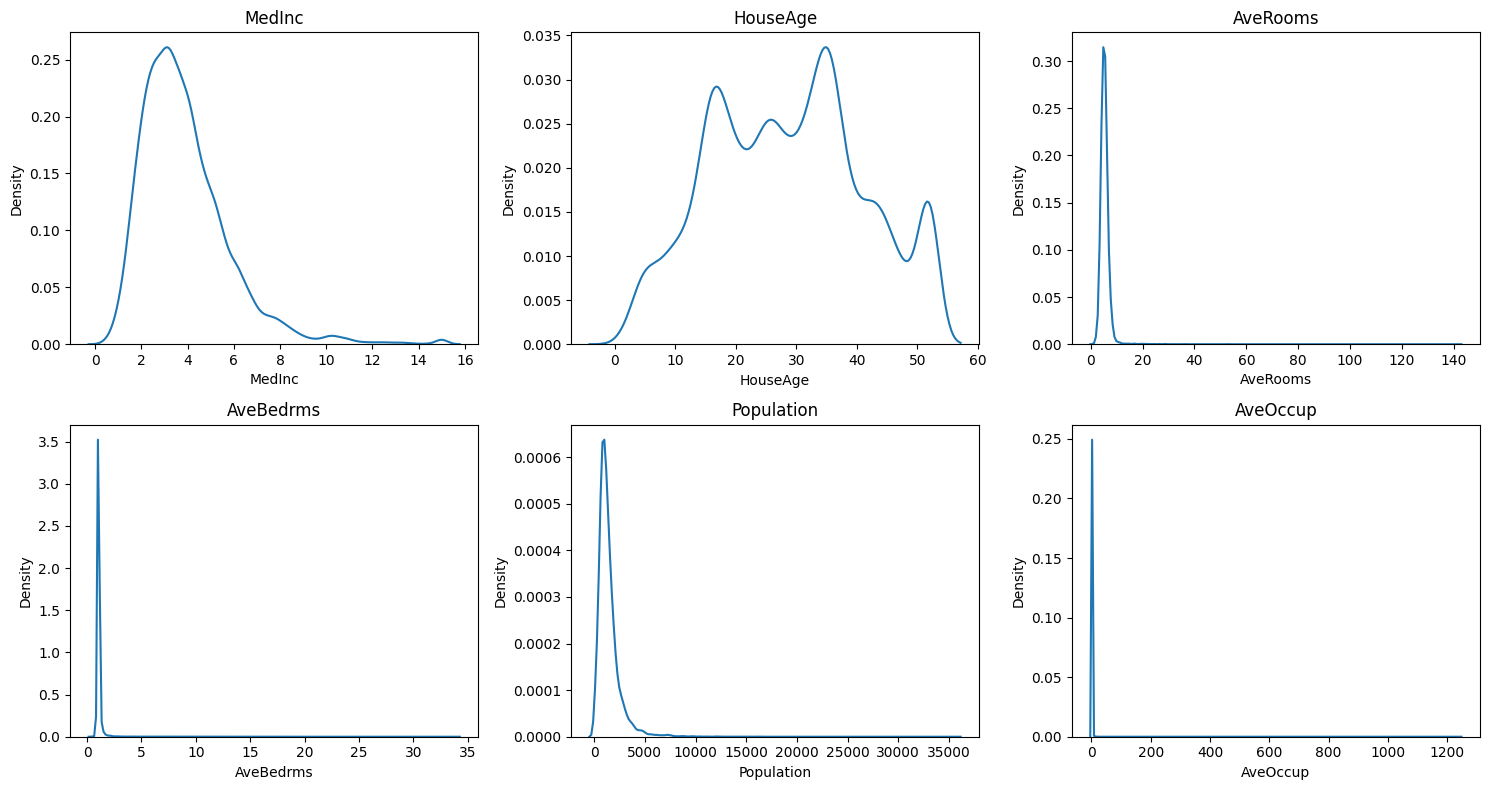

<Figure size 640x480 with 0 Axes>

In [42]:
columns = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup']

fig, axes = plt.subplots(2, 3, figsize = (15, 8))
axes = axes.flatten()
for ax, col in zip(axes, columns):
    sns.kdeplot(data = df, x = col, ax = ax, fill = False)
    ax.set_title(col)

plt.tight_layout()
plt.show()
plt.savefig("plots/data_distribution_non_normalized.png")